In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [3]:
!pip -q install torch torchvision --extra-index-url https://download.pytorch.org/whl/cpu -U
import os, zipfile, shutil, random
from google.colab import files
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 72.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.4 requires torch<2.9,>=1.10, but you have torch 2.9.0+cpu which is incompatible.
torchaudio 2.8.0+cu126 requires torch==2.8.0, but you have torch 2.9.0+cpu which is incompatible.


In [4]:
uploaded = files.upload()
zip_name = next(iter(uploaded))
zip_name

Saving sample_computer_vision.zip to sample_computer_vision.zip


'sample_computer_vision.zip'

In [5]:

data_root = "/content/data"
os.makedirs(data_root, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall(data_root)

def get_top_dir(root):
    entries = [os.path.join(root, d) for d in os.listdir(root)]
    dirs = [p for p in entries if os.path.isdir(p)]
    if len(dirs) == 1:
        return dirs[0]
    return root

data_dir = get_top_dir(data_root)
print("data_dir:", data_dir)
print("하위 항목:", os.listdir(data_dir)[:10])


data_dir: /content/data/sample_computer_vision
하위 항목: ['val', 'train']


**Load Data**

In [6]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/data/sample_computer_vision'

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                   shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda:0 device


**Visualize a few images**

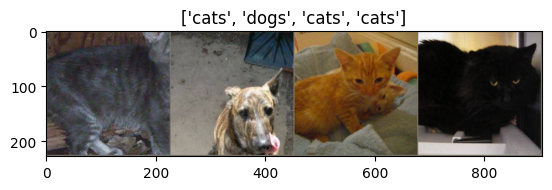

In [7]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

**Training the model**

In [8]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

**Visualizing the model predictions**

In [9]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

**Finetuning the ConvNet**

In [10]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


**Train and evaluate**

In [11]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5212 Acc: 0.7655
val Loss: 0.2315 Acc: 0.8950

Epoch 1/24
----------
train Loss: 0.5050 Acc: 0.8084
val Loss: 0.3460 Acc: 0.8400

Epoch 2/24
----------
train Loss: 0.4974 Acc: 0.8004
val Loss: 0.1140 Acc: 0.9800

Epoch 3/24
----------
train Loss: 0.5069 Acc: 0.8064
val Loss: 0.1550 Acc: 0.9350

Epoch 4/24
----------
train Loss: 0.4620 Acc: 0.8194
val Loss: 0.1229 Acc: 0.9800

Epoch 5/24
----------
train Loss: 0.5078 Acc: 0.8253
val Loss: 0.1114 Acc: 0.9700

Epoch 6/24
----------
train Loss: 0.4661 Acc: 0.8184
val Loss: 0.2452 Acc: 0.9050

Epoch 7/24
----------
train Loss: 0.3687 Acc: 0.8463
val Loss: 0.1178 Acc: 0.9650

Epoch 8/24
----------
train Loss: 0.2865 Acc: 0.8643
val Loss: 0.1287 Acc: 0.9600

Epoch 9/24
----------
train Loss: 0.2817 Acc: 0.8802
val Loss: 0.1134 Acc: 0.9650

Epoch 10/24
----------
train Loss: 0.2943 Acc: 0.8693
val Loss: 0.1041 Acc: 0.9650

Epoch 11/24
----------
train Loss: 0.2865 Acc: 0.8762
val Loss: 0.1044 Acc: 0.9650

Ep

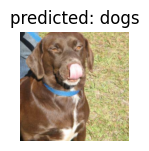

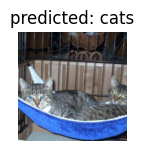

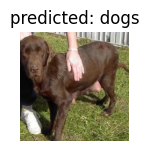

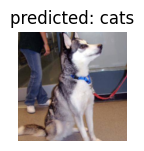

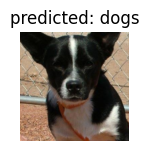

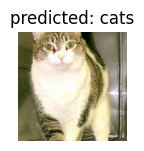

In [12]:
visualize_model(model_ft)

In [13]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [14]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5053 Acc: 0.7635
val Loss: 0.1489 Acc: 0.9550

Epoch 1/24
----------
train Loss: 0.5526 Acc: 0.7934
val Loss: 0.1209 Acc: 0.9750

Epoch 2/24
----------
train Loss: 0.5601 Acc: 0.8124
val Loss: 0.1131 Acc: 0.9800

Epoch 3/24
----------
train Loss: 0.5409 Acc: 0.8084
val Loss: 0.1332 Acc: 0.9550

Epoch 4/24
----------
train Loss: 0.3949 Acc: 0.8373
val Loss: 0.1108 Acc: 0.9600

Epoch 5/24
----------
train Loss: 0.4771 Acc: 0.8194
val Loss: 0.1016 Acc: 0.9800

Epoch 6/24
----------
train Loss: 0.4038 Acc: 0.8253
val Loss: 0.1178 Acc: 0.9800

Epoch 7/24
----------
train Loss: 0.3809 Acc: 0.8443
val Loss: 0.1139 Acc: 0.9750

Epoch 8/24
----------
train Loss: 0.3604 Acc: 0.8413
val Loss: 0.1175 Acc: 0.9700

Epoch 9/24
----------
train Loss: 0.3771 Acc: 0.8513
val Loss: 0.1103 Acc: 0.9750

Epoch 10/24
----------
train Loss: 0.3373 Acc: 0.8413
val Loss: 0.1171 Acc: 0.9700

Epoch 11/24
----------
train Loss: 0.3493 Acc: 0.8533
val Loss: 0.1149 Acc: 0.9750

Ep

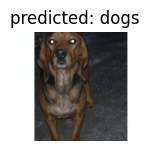

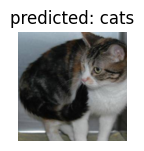

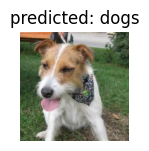

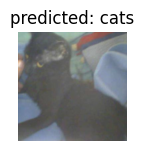

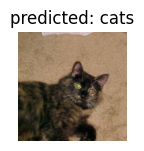

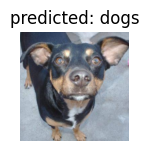

In [15]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [16]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

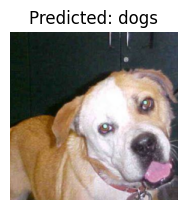

In [21]:
visualize_model_predictions(
    model_conv,
    img_path='/content/data/sample_computer_vision/val/dogs/dog.4068.jpg'
)

plt.ioff()
plt.show()